# INFEWS Farm Model

## Objective and Prerequisites

This model is based of the example of a stochastic optimization problem from [Gurobi](https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/). That problem asked you to consider a situation where you have to buy today the stock of products to sell tomorrow but you don't know the exact demand you will see. Then you will have to decide what to do with whatever is left which includes selling it for scrap. This is called the Newspaper Vendor Problem. 


---
## Problem Description

For our problem a farm must decide how to prepare for different climate futures. Each climate future has different precipation patterns that will affect how much irrigation water is needed for different plants. Our farm must decide if and how much alternative water and electricity to invest in. Using a combination of precipation, alternative water, and irrigation water the decision makers maximizes profit where revenue is based on the price of the crop and the yield available and the costs are the costs of investing in alternative water and buying irrigation water. There are known costs associated with buying irrigation water, investing in alternative water, but the unknown is knowing how much water will be available as rain.

Our model has three indicies related to climate, season, and option. 

The climate index has to do with what the possible climate futures. In this model there are 3 climate futures.


| Climate | Description |
| --- | --- |
| C1 |  DFW Historical Precipitation |
| C2 |  Lubbock Historical Precipitation |
| C3 |  San Angelo Historical Precipitation |

The season index has to do with the number of growing seasons. In this model there are 5 growing seasons.

| Season | Description |
| --- | --- |
| S1 | Growing Season 1 that correlates with the first year |
| S2 | Growing Season 2 that correlates with the second year |
| S3 | Growing Season 3 that correlates with the third year |
| S4 | Growing Season 4 that correlates with the fourth year |
| S5 | Growing Season 5 that correlates with the fifth year |

The option index correlates to the possible precipatation values in each climate scenario. There are 5 options in each climate scenario

| Season | Description |
| --- | --- |
| O1 | Option 1 that correlates with a possible realization for a given climate scenario |
| O2 | Option 2 that correlates with a possible realization for a given climate scenario |
| O3 | Option 3 that correlates with a possible realization for a given climate scenario |
| O4 | Option 4 that correlates with a possible realization for a given climate scenario |
| O5 | Option 5 that correlates with a possible realization for a given climate scenario |



---
## Model Formulation

### Sets and Indices

$k \in \text{Climate}=\{\text{C1}, \text{C2}, \text{C3}\}$

$i \in \text{Season}=\{\text{S1}, \text{S2}, \text{S3}, \text{S4}, \text{S5}\}$

$j \in \text{Option}=\{\text{O1}, \text{O2}, \text{O3}, \text{O4}, \text{O5}\}$

$\text{Sets} = \text{Climate} \cup \text{Season} \cup \text{Option}$

### Parameters

$\text{alt_water}_{k} \in \mathbb{R}^+$: The amount of alternative water for climate scenario $k$

$\text{ha} \in \mathbb{R}^+$: Hectacres

$\text{price} \in \mathbb{R}^+$: Price of crop in tons

$\text{cost alt water} \in \mathbb{R}^+$: Cost of alternative water

$\text{salt concentration water} \in \mathbb{R}^+$: The salt concentration of water

$\text{salt concentration} \in \mathbb{R}^+$: The salt concentration of soil

$\text{alt water} \in \mathbb{R}^+$: The salt concentration of water





### Decision Variables

$\text{water}_{k,i,j} \in \mathbb{N}^+$: How much water to use for climate $k$, during season $i$, and option $j$. 

$\text{irrigation_water}_{k,i,j} \in \mathbb{N}^+$: How much irrigation water to buy for climate $k$, during season $i$, and option $j$. 

$\text{climate_choice} \in \mathbb{N}^+$:Which climate option do you choose

$\text{crop_yield}_{k,i,j} \in \mathbb{N}^+$: The yield based on the amount of water used in climate $k$, during season $i$, and option $j$. 


### Objective Function

- **Cost**: Minimize total shipping costs.

\begin{equation}
\text{Maximize} \quad Z = \sum_{(k,i,j) \in \text{Sets} \times \text{Sets}}
{\text{crop_yield}_{k,i,j} \times \text{ha} \times \text{price} - 
\text{alt_water}_{k} \times \text{cost_alt_water} \times \text{climate_choice}_{k} -
\text{irrigation_water}_{k,i,j} \times \text{cost_irrigation_water} }
\end{equation}

### Constraints

- **Water Used**: Water used must be less than or equal to the sum of the rain, irrigation, and alternative water.

\begin{equation}
\text{rain}_{k,i,j} + \text{climate_choice}_{k} \times \text{alt_water}_{k} + \text{irrigation_water}_{k,i,j} \geq \text{water}_{k,i,j} 
\quad \forall k \in \text{Climate} \quad \forall i \in \text{Season} \quad \forall j \in \text{Option}
\end{equation}

- **Crop Yield**: Crop yield is based on a production function based on water depth .

\begin{equation}
\sum_{s \in \text{Sets}}{\text{crop_yield}_{k,i,j} \leq -3.35 + 0.2064 \times \text{water}_{k,i,j} - 0.0014 \times \text{water}_{k,i,j}^2 + 2.326 \times \text{salt_conc_water}^2 - 2.031 \times \text{salt_conc} + 2.326 \times \text{salt_conc}^2 } - 0.071 \times \text{water}_{k,i,j} \times \text{salt_conc_water} + 0.033 \times \text{water}_{k,i,j} \times \text{salt_conc}  
\quad \forall k \in \text{Climate} \quad \forall i \in \text{Season} \quad \forall j \in \text{Option}
\end{equation}


- **Climate Choice**: Must choose one climate choice

\begin{equation}
\sum_{k \in Climate} {\text{Climate}_{k} } = 1
\end{equation}

---
## Python Implementation

We import the Gurobi Python Module and other Python libraries.

Import Libraries, Helpful Links, and Making Sure all Results show after each chunk.

In [62]:
from gurobipy import * 
import gurobipy as gp
import random
random.seed(a=100)
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import gridspec
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Problem Source: https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/
# Matplotlib documentation: https://matplotlib.org/tutorials/introductory/pyplot.html
# Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html

In [95]:
# CSV improts

ptest = pd.read_csv('precips_c1.csv', index_col=0)

ptest

ptest.set_index(['run','year']).T.to_dict('records')

,run,year,precip
1,1,1,26.67
2,1,2,26.67
3,1,3,8.89
4,1,4,80.01
5,1,5,26.67
...,...,...,...
24996,1000,21,26.67
24997,1000,22,8.89
24998,1000,23,53.34
24999,1000,24,26.67


[{(1, 1): 26.67,
  (1, 2): 26.67,
  (1, 3): 8.89,
  (1, 4): 80.01,
  (1, 5): 26.67,
  (1, 6): 26.67,
  (1, 7): 8.89,
  (1, 8): 53.34,
  (1, 9): 26.67,
  (1, 10): 80.01,
  (1, 11): 26.67,
  (1, 12): 8.89,
  (1, 13): 53.34,
  (1, 14): 26.67,
  (1, 15): 8.89,
  (1, 16): 53.34,
  (1, 17): 8.89,
  (1, 18): 26.67,
  (1, 19): 53.34,
  (1, 20): 53.34,
  (1, 21): 53.34,
  (1, 22): 26.67,
  (1, 23): 53.34,
  (1, 24): 26.67,
  (1, 25): 26.67,
  (2, 1): 53.34,
  (2, 2): 26.67,
  (2, 3): 53.34,
  (2, 4): 53.34,
  (2, 5): 26.67,
  (2, 6): 26.67,
  (2, 7): 53.34,
  (2, 8): 8.89,
  (2, 9): 8.89,
  (2, 10): 26.67,
  (2, 11): 53.34,
  (2, 12): 53.34,
  (2, 13): 53.34,
  (2, 14): 53.34,
  (2, 15): 26.67,
  (2, 16): 26.67,
  (2, 17): 26.67,
  (2, 18): 26.67,
  (2, 19): 53.34,
  (2, 20): 53.34,
  (2, 21): 26.67,
  (2, 22): 26.67,
  (2, 23): 8.89,
  (2, 24): 26.67,
  (2, 25): 26.67,
  (3, 1): 8.89,
  (3, 2): 8.89,
  (3, 3): 8.89,
  (3, 4): 80.01,
  (3, 5): 8.89,
  (3, 6): 26.67,
  (3, 7): 8.89,
  (3, 8): 26

Some helpful conversions.
And some parameterization and upper and lower bounds.

In [63]:
# Conversions

cm2_ha = 100000000 # 100,000,000 cm2 = 1 ha

cm3_gal = 3785.41 # 3785.41 cm2 = 1 Gal

gal_acre_ft = 325851 # 1 acre ft = 325851 gallons

acre_ha = 2.47105 # 1 hectare = 2.47105 acres

cm_ft = 30.48 # 1 ft = 30.48 cm

cm_in = 2.54

lb_tonne = 2204.62

# Parameters

ha = 10 # hectares

price = 200 # $/ metric ton #https://www.indexmundi.com/commodities/?commodity=wheat

#note $ /acre ranges from $7-85 / acre assuming only a few cm of depth similiar price to irrigation water 

cost_alt_water = 60 # $ / cm



# Irrigation Water Cost https://news.berkeley.edu/berkeley_blog/the-cost-of-irrigation-water-and-urban-farming/
#  Given in $ / cm from: $ 40 / acre-ft / gal_acre_ft / cm3_gal * cm2_ha * ha 

cost_irrigation_water = 40 / gal_acre_ft / cm3_gal * cm2_ha * ha  # $ / cm 


salt_conc = 2 # deciSiemens / meter = dS/m

salt_conc_water = 1 # deciSiemens / meter = dS/m

precip = 20 * cm_in # 20 inches of rain


irrigation_water_limit = 0.75 # acre-ft / acre https://www.nass.usda.gov/Publications/Highlights/2019/2017Census_Irrigation_and_WaterManagement.pdf

max_irrigation_water = irrigation_water_limit * cm_ft



#Renewable Energy

# Capacity Factor Solar https://pv-magazine-usa.com/2018/07/03/texas-getting-315-mw-of-solar-power/

cf_solar = 0.30

# Fu, R., Feldman, D., Margolis, R., 2018. U.S. Solar Photovoltaic System Cost Benchmark: Q1 2018. Tech. rep., National Renewable Energy Laboratory, Golden, CO.

solar_dollar_kW = 1.5

# wInd Costs https://www.energy.gov/sites/prod/files/2019/08/f65/2018%20Wind%20Technologies%20Market%20Report%20FINAL.pdf

wind_dollar_kW = 0.8






Seeting the precipatation values.

This is where I can create climate regimes. 

Have certain climate regimes have certain values of precipatation

In [64]:
# Precipation Data from weather.gov NOWData NOAA Online Weather Data from 1990-2020 for DFW, Lubbock, and San Angelo
# Climate Zones https://www.energy.gov/sites/prod/files/2015/10/f27/ba_climate_region_guide_7.3.pdf
# NOAA Climate Zones https://scijinks.gov/climate-zones/

precip = [1 , 2 , 3 , 4 , 5 ,6 ,7 ,8 , 9 , 10 ,11 ,12]
precip = [x*4 for x in precip]


len(precip)
samples = len(precip)

12

A quick chart showing the effect of water depth on yield and price.

Text(0.5, 1.0, 'Profit and Yield by Preciptation')

Text(0.5, 0, 'Water Depth (cm)')

Text(0, 0.5, 'Profit ($)')

(-100.0, 7200.0)

Text(0, 0.5, 'Yield (tonnes/ha)')

(-100.0, 8500.0)

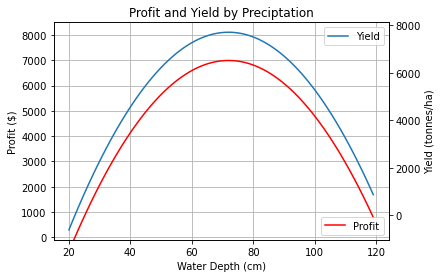

In [65]:
alt_water = 0
irrigation_water = 0
#irrigation_water = np.array(range(100))
water = np.array(range(100))+20
#water = alt_water + irrigation_water + precip

# From Dinar et. al 1991 "Production functions relating crop yield, water quality and quantity, soil salinity and drainage volume"

y1 = (-3.350 + 0.2064*water - 0.0014*water*water + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water 
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc
               -0.071 * water * salt_conc_water + 0.033 * water * salt_conc 
               -2.754 * salt_conc_water * salt_conc)

p1 = (y1*ha*price +
              -alt_water * (ha*cm2_ha/cm3_gal) * cost_alt_water +
              -irrigation_water * (ha*cm2_ha/cm3_gal) * cost_irrigation_water )

fig, ax = plt.subplots()

ax.plot(water,p1, label = 'Profit', color = 'red') # profit is red line
ax.set_title('Profit and Yield by Preciptation')
ax.set_xlabel('Water Depth (cm)')
ax.set_ylabel('Profit ($)')
ax.set_ylim([-100,7200])
ax.grid(True)
ax.legend(loc = 'lower right')

ax2 = ax.twinx()
ax2.plot(water,y1*lb_tonne, label = 'Yield') # yield is blue line
ax2.set_ylabel('Yield (tonnes/ha)')
ax.set_ylim([-100,8500])
ax2.legend()
plt.show()


#plt.plot(irrigation_water,p1)








Another useful bound to speed up computational time. The max price is as good as it gets and since the above code doesn't have any cost max price is max rev.

This code defines the charts that are used in the other Stochastic programs.

In [66]:
# Conditional value at risk (for losses) is the expected value of the worst alpha% tail of the realizations 
# in the random variable (represented in this case as a list of values)
# alpha: a value in ]0,1[
# data: a list of values
def CVaR(data,alpha):
    data.sort()
    n = len(data)
    m = int(alpha*n)
    return sum(data[m:-1])/len(data[m:-1])

# Prints the double histogram of a random variable (represented in this case as a list of values)
# First the empirical density distribution, and then the empirical accumulated probability

n_bins = 150

def doubleHist(data, xlabel=None):
    plt.figure(figsize=(14.5,6),dpi=600)
    gs  = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.25)
    ax  = plt.subplot(gs[0])
    ax3 = plt.subplot(gs[1])
    ax.grid(True)
    ax.set_title(xlabel)
    ax.set_ylabel('Likelihood of occurrence',color='blue')
    ax2 = ax.twinx()
    ax2.set_ylabel('Cumulative probability',color='red')
    # plot the density and cumulative histogram
    n, bins, patches = ax.hist(data, n_bins, density=True, alpha=0.65, cumulative=False, label='Density', color='blue')
    n, bins, patches = ax2.hist(data, n_bins, density=True, histtype='step', cumulative=True, label='CDF', color='red')
    ax3.boxplot(data,whis=[5,95])
    # tidy up the figure
    plt.show()

#print basic info on optimal solution
def solutionStats(model, order, losses):
    global cost_alt_water
    losses.sort()
    samples = len(losses)
    print('Model Value', m.ObjVal, 'order Qty', alt_water.X, 'investment', alt_water.X*cost_alt_water, '#samples',samples)
    print('Losses stats:')
    print('CVaR(95%,90%,80%,70%)', CVaR(losses,0.95), CVaR(losses,0.90), CVaR(losses, 0.80), CVaR(losses,0.70))
    print('min', min(losses),'max', max(losses), 'average', sum(losses)/samples, 'VaR_75%', losses[int(0.75*samples)])

Defines the stochastic model. This model is simply a weighted average. Takes each possible precipatation and its corresponding yield and profit and averages them equally.

Variabels

alt_water; irrigation_water

water

crop_yield, profit

Objective functions are all profit and correspond to the different precipation scenarios. Need to change this to climaate scenarios.

Water is function of precipitation, alternative water and irrigation water.

Crop yield is function of saliniatity, soil, and water.


In [67]:
# To help get tight bounds on variables later on

maxrev  = max(p1)
minrev  = 0

#Water peaks profit and yield at 73

alt_water = max((73 - max_irrigation_water - min(precip)*cm_in/2),0)

maxrev



6992.400000000002

Showing all the results for each precipation scenario. Need to change this to climate scenario.

In [68]:
run = list(range(3))
run = [x+1 for x in run]
year = list(range(4))
year = [x+1 for x in year]
run
year


indicies = [(r,y) for r in run for y in year]
indicies

rain = {}

for i in range(len(indicies)):
    rain[indicies[i]] = precip[i]/4

precip
rain
len(indicies)
samples = len(indicies)


[1, 2, 3]

[1, 2, 3, 4]

[(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4)]

[4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]

{(1, 1): 1.0,
 (1, 2): 2.0,
 (1, 3): 3.0,
 (1, 4): 4.0,
 (2, 1): 5.0,
 (2, 2): 6.0,
 (2, 3): 7.0,
 (2, 4): 8.0,
 (3, 1): 9.0,
 (3, 2): 10.0,
 (3, 3): 11.0,
 (3, 4): 12.0}

12

Showing results of Profit Expected Value for CVaR 95%.

The second model where the CVaR is 75%. Instead of a weighted average model which Takes each possible precipatation and its corresponding yield and profit and averages them equally. This model uses the CVaR method.


In [69]:
m = Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions, pick what climate you are in which automatically picks how much alternative water to invest in

alt_water = m.addVar(name = 'alt_water') # cm of depth




#Second Stage Decision Variables Operational Decisions, Pick how much water to use and how much irrigation water to buy

# Change these variables to be a function of option, climate, and season
water = m.addVars(run, year, lb = 0, name = 'water') # water used for crop, cm of depth
irrigation_water = m.addVars(run, year, lb = 0, ub = max_irrigation_water, name = 'irrigation_water') # cm of depth

#Functions of the Above, also functions of option, climate, and season, 
crop_yield = m.addVars(run, year, name = 'yield') # tonne/ha
profit = m.addVars(run, year, obj = 1/samples, name = 'profit') # $



#Maybe add a new profit variable that is the sum of the profit based on climate for easy coefficients



# Objective

m.addConstrs( (profit[r,y] == crop_yield[r,y] * ha * price +
              -alt_water * cost_alt_water +
              -irrigation_water[r,y] * cost_irrigation_water
             for r in run for y in year)
            ,name = 'profit')


# Set Constraints



m.addConstrs( (rain[r,y] + alt_water + irrigation_water[r,y] >= water[r,y] 
              for r in run for y in year)
            ,name = 'water' )



for r in run:
    for y in year :
            m.addQConstr( (crop_yield[r,y] <= -3.350 + 0.2064*water[r,y]  - 0.0014*water[r,y]*water[r,y]  + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[r,y]  * salt_conc_water + 0.033 * water[r,y]  * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();




In [70]:
m.optimize()
obj = m.getObjective()
print(obj.getValue())


Gurobi Optimizer version 9.1.1 build v9.1.1rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 24 rows, 49 columns and 84 nonzeros
Model fingerprint: 0xf7a4730c
Model has 12 quadratic constraints
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [8e-02, 8e-02]
  Bounds range     [2e+01, 2e+01]
  RHS range        [1e+00, 1e+01]
  QRHS range       [4e+00, 4e+00]
Presolve time: 0.02s
Presolved: 60 rows, 73 columns, 156 nonzeros
Presolved model has 12 second-order cone constraints
Ordering time: 0.00s

Barrier statistics:
 Dense cols : 1
 AA' NZ     : 1.200e+02
 Factor NZ  : 2.410e+02
 Factor Ops : 1.081e+03 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   4.66079073e+02  1.56430137e+03  4.32e+01 5.73e+00 

In [79]:
profit_dict = m.getAttr('x', profit)
crop_yield_dict = m.getAttr('x', crop_yield)
water_dict = m.getAttr('x', water)
irrigation_water_dict = m.getAttr('x', irrigation_water)


profit_dict
crop_yield_dict
water_dict
irrigation_water_dict
rain

{(1, 1): 3605.1387473723,
 (1, 2): 3692.878375465846,
 (1, 3): 3775.018009471315,
 (1, 4): 3851.557652733058,
 (2, 1): 3922.4973141536807,
 (2, 2): 3987.8369598785685,
 (2, 3): 4047.5765136699692,
 (2, 4): 4101.716061113355,
 (3, 1): 4150.255457736948,
 (3, 2): 4193.194917026706,
 (3, 3): 4230.533162627572,
 (3, 4): 4263.360505877466}

{(1, 1): 3.1302515729987084,
 (1, 2): 3.1741213836346787,
 (1, 3): 3.2151911972480067,
 (1, 4): 3.2534610163928694,
 (2, 1): 3.288930848432105,
 (2, 2): 3.321600677324913,
 (2, 3): 3.3514704090223537,
 (2, 4): 3.378540112684036,
 (3, 1): 3.402809477009534,
 (3, 2): 3.4242790006193,
 (3, 3): 3.442938885538884,
 (3, 4): 3.44926024177499}

{(1, 1): 55.76078444534012,
 (1, 2): 56.76078412746183,
 (1, 3): 57.760783807694324,
 (1, 4): 58.76078354908227,
 (2, 1): 59.7607835952939,
 (2, 2): 60.76078392315864,
 (2, 3): 61.760780245557115,
 (2, 4): 62.760774995419304,
 (3, 1): 63.76075151893817,
 (3, 2): 64.7607392552793,
 (3, 3): 65.76016073696114,
 (3, 4): 66.13773016827012}

{(1, 1): 22.8599981973205,
 (1, 2): 22.859997986962707,
 (1, 3): 22.85999777792451,
 (1, 4): 22.85999762460246,
 (2, 1): 22.85999770656252,
 (2, 2): 22.859998078479073,
 (2, 3): 22.859995290922434,
 (2, 4): 22.8599909700426,
 (3, 1): 22.85997037177775,
 (3, 2): 22.85995766477197,
 (3, 3): 22.85938792787759,
 (3, 4): 22.236954653321177}

{(1, 1): 1.0,
 (1, 2): 2.0,
 (1, 3): 3.0,
 (1, 4): 4.0,
 (2, 1): 5.0,
 (2, 2): 6.0,
 (2, 3): 7.0,
 (2, 4): 8.0,
 (3, 1): 9.0,
 (3, 2): 10.0,
 (3, 3): 11.0,
 (3, 4): 12.0}

In [80]:
#Changing Tuple Dictionary to Dataframe

profit_df = pd.Series(profit_dict).reset_index()
profit_df.columns = ['run', 'year', 'profit'] 

crop_yield_df = pd.Series(crop_yield_dict).reset_index()
crop_yield_df.columns = ['run', 'year', 'crop_yield'] 

water_df = pd.Series(water_dict).reset_index()
water_df.columns = ['run', 'year', 'water depth'] 

irrigation_water_df = pd.Series(irrigation_water_dict).reset_index()
irrigation_water_df.columns = ['run', 'year', 'water depth'] 

rain_df = pd.Series(rain).reset_index()
rain_df.columns = ['run', 'year', 'water depth'] 

profit_df
crop_yield_df
water_df
irrigation_water_df
rain_df

,run,year,profit
0,1,1,3605.138747
1,1,2,3692.878375
2,1,3,3775.018009
3,1,4,3851.557653
4,2,1,3922.497314
5,2,2,3987.836960
6,2,3,4047.576514
7,2,4,4101.716061
8,3,1,4150.255458
9,3,2,4193.194917


,run,year,crop_yield
0,1,1,3.130252
1,1,2,3.174121
2,1,3,3.215191
3,1,4,3.253461
4,2,1,3.288931
5,2,2,3.321601
6,2,3,3.351470
7,2,4,3.378540
8,3,1,3.402809
9,3,2,3.424279


,run,year,water depth
0,1,1,55.760784
1,1,2,56.760784
2,1,3,57.760784
3,1,4,58.760784
4,2,1,59.760784
5,2,2,60.760784
6,2,3,61.760780
7,2,4,62.760775
8,3,1,63.760752
9,3,2,64.760739


,run,year,water depth
0,1,1,22.859998
1,1,2,22.859998
2,1,3,22.859998
3,1,4,22.859998
4,2,1,22.859998
5,2,2,22.859998
6,2,3,22.859995
7,2,4,22.859991
8,3,1,22.859970
9,3,2,22.859958


,run,year,water depth
0,1,1,1.0
1,1,2,2.0
2,1,3,3.0
3,1,4,4.0
4,2,1,5.0
5,2,2,6.0
6,2,3,7.0
7,2,4,8.0
8,3,1,9.0
9,3,2,10.0


In [89]:
# Changing Dataframe to Tuple dictionary
profit_df.set_index(['run','year']).T.to_dict('records')

[{(1, 1): 3605.1387473723,
  (1, 2): 3692.878375465846,
  (1, 3): 3775.018009471315,
  (1, 4): 3851.557652733058,
  (2, 1): 3922.4973141536807,
  (2, 2): 3987.8369598785685,
  (2, 3): 4047.5765136699692,
  (2, 4): 4101.716061113355,
  (3, 1): 4150.255457736948,
  (3, 2): 4193.194917026706,
  (3, 3): 4230.533162627572,
  (3, 4): 4263.360505877466}]

In [ ]:
#df.to_csv('myDataFrame.csv')



In [73]:
ycy = np.array(0)
yp = np.array(0)
yiw = np.array(0)
yw = np.array(0)
yrain = np.array(0)

for i in year:
    ycy = np.append(ycy,np.mean([crop_yield[r,i].X for r in run]))
    yp = np.append(yp,np.mean([profit[r,i].X for r in run]))
    yiw = np.append(yiw,np.mean([irrigation_water[r,i].X for r in run]))
    yw = np.append(yw,np.mean([water[r,i].X for r in run]))
    yrain = np.append(yrain,np.mean([rain[r,i] for r in run]))
    
ycy = ycy[1:(len(year)+1)]
yp = yp[1:(len(year)+1)]
yiw = yiw[1:(len(year)+1)]
yw = yw[1:(len(year)+1)]
yrain = yrain[1:(len(year)+1)]

ycy
yp
yiw
yw
yrain

xs = list(range(len(year)))
xs


array([3.2739973 , 3.30666702, 3.3365335 , 3.36042046])

array([3892.63050642, 3957.97008412, 4017.70922859, 4072.21140657])

array([22.85998876, 22.85998458, 22.85979367, 22.65231442])

array([59.76077319, 60.7607691 , 61.76057493, 62.55309624])

array([5., 6., 7., 8.])

[0, 1, 2, 3]

In [74]:
rcy = np.array(0)
rp = np.array(0)
riw = np.array(0)
rw = np.array(0)
rrain = np.array(0)

for r in run:
    rcy = np.append(rcy,np.mean([crop_yield[r,y].X for y in year]))
    rp = np.append(rp,np.mean([profit[r,y].X for y in year]))
    riw = np.append(riw,np.mean([irrigation_water[r,y].X for y in year]))
    rw = np.append(rw,np.mean([water[r,y].X for y in year]))
    rrain = np.append(rrain,np.mean([rain[r,y] for y in year]))
    
rcy = rcy[1:(len(run)+1)]
rp = rp[1:(len(run)+1)]
riw = riw[1:(len(run)+1)]
rw = rw[1:(len(run)+1)]
rrain = rrain[1:(len(run)+1)]

rcy
rp
riw
rw
rrain


xr = list(range(len(run)))
xr





array([3.19325629, 3.33513551, 3.4298219 ])

array([3731.14819626, 4014.9067122 , 4209.33601082])

array([22.8599979 , 22.85999551, 22.70406765])

array([57.26078398, 61.26078069, 65.10484542])

array([ 2.5,  6.5, 10.5])

[0, 1, 2]

Text(0.5, 1.0, 'Profit and Yield by Preciptation')

Text(0.5, 0, 'Possible Outcome')

Text(0, 0.5, 'Profit ($) & Yield (lbs)')

(0.0, 8000.0)

Text(0, 0.5, 'Water (cm)')

(0.0, 100.0)

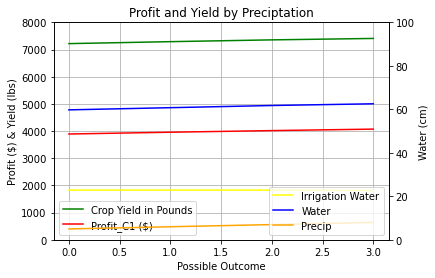

In [75]:
fig, ax = plt.subplots()

ax.plot(xs,ycy*lb_tonne, label = 'Crop Yield in Pounds', color = 'green') # profit is red line
ax.plot(xs,yp, label = 'Profit_C1 ($)', color = 'red') # profit is red line
ax.set_title('Profit and Yield by Preciptation')
ax.set_xlabel('Possible Outcome')
ax.set_ylabel('Profit ($) & Yield (lbs)')
ax.set_ylim([0,8000])
ax.grid(True)
ax.legend(loc = 'lower left')

ax2 = ax.twinx()
ax2.plot(xs,yiw, label = 'Irrigation Water', color = 'yellow') # irrigation is blue line
ax2.plot(xs,yw, label = 'Water', color = 'blue') # water is green line
ax2.plot(xs,yrain, label = 'Precip', color = 'orange') # water is green line
ax2.set_ylabel('Water (cm)')
ax2.set_ylim([0,100])
ax2.legend(loc='lower right')


plt.show()

Text(0.5, 1.0, 'Profit and Yield by Preciptation')

Text(0.5, 0, 'Possible Outcome')

Text(0, 0.5, 'Profit ($) & Yield (lbs)')

(0.0, 8000.0)

Text(0, 0.5, 'Water (cm)')

(0.0, 100.0)

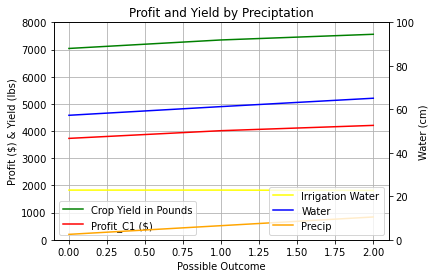

In [76]:
fig, ax = plt.subplots()

ax.plot(xr,rcy*lb_tonne, label = 'Crop Yield in Pounds', color = 'green') # profit is red line
ax.plot(xr,rp, label = 'Profit_C1 ($)', color = 'red') # profit is red line
ax.set_title('Profit and Yield by Preciptation')
ax.set_xlabel('Possible Outcome')
ax.set_ylabel('Profit ($) & Yield (lbs)')
ax.set_ylim([0,8000])
ax.grid(True)
ax.legend(loc = 'lower left')

ax2 = ax.twinx()
ax2.plot(xr,riw, label = 'Irrigation Water', color = 'yellow') # irrigation is blue line
ax2.plot(xr,rw, label = 'Water', color = 'blue') # water is green line
ax2.plot(xr,rrain, label = 'Precip', color = 'orange') # water is green line
ax2.set_ylabel('Water (cm)')
ax2.set_ylim([0,100])
ax2.legend(loc='lower right')


plt.show()

The just CVaR method didn't work out to hot so I did a mix of 50% CVAR 75% and 50% mix of just a weighted average.